In [ ]:
# !pip install tensorflow

In [ ]:
import numpy as np
import pandas as pd
import joblib
import category_encoders as ce
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, FunctionTransformer
# from sklearn.pipeline import Pipeline
from features import add_features
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay,confusion_matrix,classification_report,precision_recall_curve,f1_score
import tensorflow as tf
from tensorflow import keras



In [21]:
df = pd.read_csv("car_insurance_fraud_dataset.csv")
df.head()

,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,...,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,POL100000,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,...,MI,Charlesville,6,1,4,0,Yes,8161.36,11677.60,Y
1,POL100001,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,...,OH,Joshuaberg,0,3,4,5,No,18561.79,18027.81,N
2,POL100002,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,...,MI,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59,N
3,POL100003,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,...,NC,Josephchester,22,3,3,5,No,13188.92,14204.34,N
4,POL100004,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,...,NY,Caitlinfort,18,4,2,4,No,21864.69,24038.84,N


In [22]:
df.drop(columns='policy_id', inplace=True)
df['authorities_contacted'] = df['authorities_contacted'].fillna("No Contact")

X = df.drop(columns=[
    'fraud_reported','incident_date','policy_state',
    'incident_city','incident_state','insured_hobbies'
])

y = df['fraud_reported'].map({'Y':1,'N':0})


# **Encoding**

In [23]:
categorical_col=df.select_dtypes('object')
for col in categorical_col:
  print(col,df[col].nunique())

policy_state 10
insured_sex 3
insured_education_level 4
insured_occupation 8
insured_hobbies 7
incident_date 731
incident_type 4
collision_type 4
incident_severity 3
authorities_contacted 4
incident_state 10
incident_city 17931
police_report_available 2
fraud_reported 2


In [24]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [25]:
numeric_cols = [
    'policy_deductible','policy_annual_premium','insured_age',
    'incident_hour_of_the_day','number_of_vehicles_involved',
    'bodily_injuries','witnesses','claim_amount','total_claim_amount','police_report_available'
]

In [ ]:
X_train = add_features(X_train)
X_test  = add_features(X_test)

In [28]:
from sklearn.utils import shuffle

X_train, y_train = shuffle(X_train, y_train, random_state=42)

target_cols = ['insured_occupation','age_group']

cat_encoder = ce.CatBoostEncoder(cols=target_cols, random_state=42)

X_train = cat_encoder.fit_transform(X_train, y_train)
X_test  = cat_encoder.transform(X_test)

In [29]:
ordinal_cols = ['insured_education_level','incident_severity']

ordinal_encoder = OrdinalEncoder(categories=[
    ['High School','College','Masters','PhD'],
    ['Minor Damage','Major Damage','Total Loss']
])
X_train[ordinal_cols] = ordinal_encoder.fit_transform(X_train[ordinal_cols])
X_test[ordinal_cols]  = ordinal_encoder.transform(X_test[ordinal_cols])

# df[ordinal_cols] = ordinal_encoder.fit_transform(df[ordinal_cols])

In [30]:
one_hot_cols = [
    'insured_sex','incident_type','collision_type','authorities_contacted'
]

X_train = pd.get_dummies(X_train, columns=one_hot_cols, drop_first=True)
X_test  = pd.get_dummies(X_test, columns=one_hot_cols, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# **Oversampling**

In [32]:
from imblearn.over_sampling import KMeansSMOTE

smote = KMeansSMOTE(
    kmeans_estimator=3,
    k_neighbors=2,
    cluster_balance_threshold=0.01,
    random_state=42
)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [42]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_res, y_train_res,
    test_size=0.2,
    random_state=42,
    stratify=y_train_res
)

# **Neural Network**

 **Initialization to prevent Vanishing or Exploding Gradients**

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.initializers import HeNormal, GlorotUniform
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [37]:
model=Sequential(
    [
     Input(shape=(X_train_res.shape[1],)),
     Dense(64,activation='relu',kernel_initializer=HeNormal()),
     Dense(128,activation='relu',kernel_initializer=HeNormal()),
     Dense(1, activation='sigmoid', kernel_initializer=GlorotUniform())
    ]
)

In [38]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,369 (40.50 KB)

 Trainable params: 10,369 (40.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['f1_score'])model.compile(
    optimizer=Adam(0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [43]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)

train = model.fit(X_train_final, y_train_final, validation_data=(X_val, y_val), epochs=50, callbacks=[early_stopping, model_checkpoint])

Epoch 1/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - f1_score: 0.6544 - loss: 35.7438 - val_f1_score: 0.7108 - val_loss: 20.0793
Epoch 2/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - f1_score: 0.6595 - loss: 28.3249 - val_f1_score: 0.7021 - val_loss: 47.3829
Epoch 3/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - f1_score: 0.6708 - loss: 24.3673 - val_f1_score: 0.6944 - val_loss: 20.9401
Epoch 4/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - f1_score: 0.6738 - loss: 21.8944 - val_f1_score: 0.7549 - val_loss: 7.9324
Epoch 5/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - f1_score: 0.6760 - loss: 17.3950 - val_f1_score: 0.0079 - val_loss: 29.5136
Epoch 6/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - f1_score: 0.6834 - loss: 14.8561 - val_f1_score: 0.7088 - val_loss: 19.9487
Epoch 7/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - f1_score: 0.6817 - loss: 16.5174 - val_f1_score: 0.7655 - val_loss: 8.1432


In [44]:
from tensorflow.keras.models import load_model

best_model = load_model('best_model.keras')

In [45]:
predictions = best_model.predict(X_val)


266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [46]:
loss, acc = best_model.evaluate(X_val, y_val)
print(acc)

266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - f1_score: 0.7549 - loss: 7.9324
[0.7549321]


In [47]:
y_pred = (best_model.predict(X_val) > 0.5).astype(int)

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


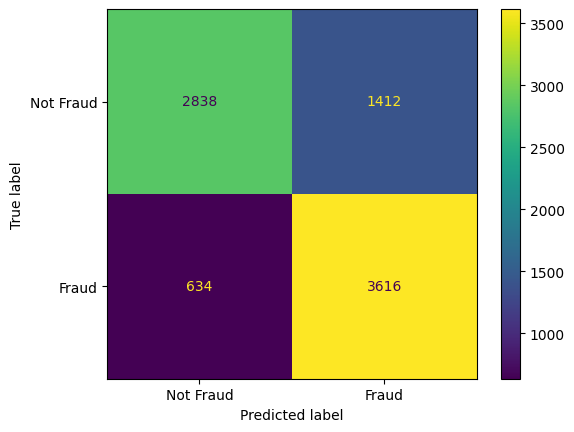

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Not Fraud','Fraud'])
disp.plot()

In [ ]:
print("\nClassification Report:\n", classification_report(y_val, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.67      0.74      4250
           1       0.72      0.85      0.78      4250

    accuracy                           0.76      8500
   macro avg       0.77      0.76      0.76      8500
weighted avg       0.77      0.76      0.76      8500

